In [18]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
# NOTE: Check if libraries are used

# Standard Libraries
import datetime
import os
import joblib
from pathlib import Path
import sys

# Geospatial and Image Processing Libraries
import rasterio
from rasterio.windows import Window
import cv2
from scipy.ndimage import binary_dilation
from scipy.stats import mode 
import numpy as np

# Matplotlib
import matplotlib as plt

# Pandas
import pandas as pd

# Machine Learning (Scikit-Learn) Libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, PredefinedSplit
from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix

In [20]:
# Modules
import sys, os

# Adds the parent directory to the path so it can find utils.py or src/
sys.path.append(os.path.abspath('..'))

import src.model_utils as model_utils
import src.inference as inference
import src.postprocessing as postprocessing
import params

# 3. Training the Random Forest Model

* **Note**: The sole input to this section is the feature stacks computed in 01_data_acquisition_and_preparation.ipynb. The feature stacks are stored in the location returned by the function call `params.feature_stacks_folder()`.


In [8]:
# The feature stacks output from 01_data_acquisition_and_preparation.ipynb 

fstack_numpy_files = list(params.feature_stacks_folder().glob("*.npy"))
fstack_meta_files = list(params.feature_stacks_folder().glob("*.pkl"))

In [9]:
for path in fstack_numpy_files:
    print(path)

..\data\westminster_data\01_data_acquisition_and_preparation\feature_stacks\tile-1_fstack.npy
..\data\westminster_data\01_data_acquisition_and_preparation\feature_stacks\tile-2_fstack.npy
..\data\westminster_data\01_data_acquisition_and_preparation\feature_stacks\tile-3_fstack.npy
..\data\westminster_data\01_data_acquisition_and_preparation\feature_stacks\tile-4_fstack.npy
..\data\westminster_data\01_data_acquisition_and_preparation\feature_stacks\tile-5_fstack.npy


## 3.1 Splitting Data into Testing and Training Sets

The GLA 2024 methodology (§2.3.3) details a straightforward method for splitting each previously labelled tile into training and testing groups for the Machine Learning model. The top 70% of the labelled area is split into **training data**, while the remaining 30% becomes **testing data**. The training data is vertically split into three **Cross-Validation (CV)** groups. Figure 5 illustrates the split:

<center>
  <figure>
    <img src="../images/gla-method-figure-5.png" alt=" GLA 2024 methodology Figure 5: Labelled data split into training and testing sets" width="70%">
    <figcaption><i>GLA 2024 methodology Figure 5: Labelled data split into training and testing sets</i></figcaption>
  </figure>
</center>

* **Note**: The Cross-Validation groups are used initially during [Hyperparameter Search](#3.2.2-Performing-the-Search). Once the best parameters are found, the CV sets are abandoned, and the model is retrained on the entire training set.

The method of splitting performed is geographic, rather than the random split used by libraries such as scikit-learn. One crucial reason lies in the fact that geographic pixels are not IID (independent and identically distributed) variables, meaning that a random subsample of pixels does not yield truly independent data. Splitting the data geographically is a more intuitive method.

To ensure objects do not geographically overlap multiple groups, the GLA methodology proposes discarding 20 rows of pixels between the training and testing groups, and 10 rows of pixels between each CV group. It is important to note that the GLA method utilises 25cm pixels. Therefore, 20 rows are equivalent to 5 meters and 10 rows to 2.5 meters. The user must calculate the spatial equivalent according to the resolution used. The function `model_utils.get_ml_model_input()` performs the aforementioned split and returns the ML-ready data.

----
**Calculating Rows to Discard for the City of Westminster Project**

Since the data used has a pixel resolution of 1 meter, 5 meters between the training and testing groups would constitute a 5 pixel gap, while the 2.5 meters between the CV groups would constitute a 2.5 pixel gap (rounded up to 3).

----

* **Note Regarding the Splitting Function**:

  `model_utils.get_ml_model_input()` performs the split shown in Figure 5 separately on each tile by calling `model_utils.prepare_spatial_split()" internally. The training and testing sets from each tile are concatenated into a single training set and a single testing set, respectively, before being returned.  

In [20]:
# Notes:

# a. 'test_gap_px' and 'cv_gap_px' depend on the satellite resolution

# b. 'train_ids' and 'test_ids' are masks that define what data belongs to which tile. The variables are used later for
# splitting the arrays back into their components.

# c. The 'folds' variable is a mask that the scikit-learn libraries may use to determine the custom cross-validation groups

X_train, y_train, X_test, y_test, folds, train_ids, test_ids = model_utils.get_ml_model_input(stack_paths=fstack_numpy_files, 
                                                                                             train_ratio=0.7, 
                                                                                             test_gap_px=5, 
                                                                                             cv_gap_px=3, 
                                                                                             n_folds=3)

Processing 5 tiles...

--- Final Dataset Dimensions ---
X_train: (154350, 42)
y_train: (154350,)
X_test:  (60900, 42)
y_test:  (60900,)
CV Folds: (154350,)
--------------------------------



* **Optional: Interpreting Dimensions of Spatial Split:**

  This is an optional explanation on how to interpret the resulting dimensions. The City of Westminster project utilised 5 tiles, each 210x210 meters. The function `model_utils.get_ml_model_input()` returns the following dimensions:

  | Variable | Dimensions |
    | :--- | :--- |
    | X_train | (154350, 42) |
    | y_train | (154350,) |
    | X_test  | (60900, 42) |
    | y_test  | (60900,) |
    | CV Folds | (154350,) |

  **The first dimension** is interpreted as follows: A 210x210 tile contains 44100 pixels. Of these 44100 pixels, 30870 are for training (70%), 12180 are for testing (30%), and 1050 pixels are discarded (5 rows, 210 pixels each). Since there are a total of 5 tiles, the total training set is: 5 * 30870 = 154350. The total testing set is: 5 * 12180 = 60900. The CV folds cover the training area only. Therefore, it shares its dimension.

  **The second dimension** for the training input data (X_train) represents the number of engineered features. The dimension (154350, 42) states that there are 42 different values (features) for each of the 154350 pixels. The same logic is applied to X_test. As for the ground truths (y) and CV folds, they are vectors with a single value for each pixel. 


## 3.2 Hyperparameter Search and Model Training

A **Random Forest (RF)** classifier is used. The GLA methodology (Appendix 3) defines the set of **Hyperparameters** that are iterated through during the Hyperparameter Search process, including settings related to individual **Decision Trees (DTs)** within the Random Forest. 

### 3.2.1 Defining the Search Space

The following parameters are iterated through during Hyperparameter Search:

<br>

* **Number of DTs:** The number of Decision Trees used to form the Random Forest.
Each DT gets one ‘vote’ towards a prediction.

* **Maximum DT Depth:** The maximum depth of each DT (maximum number of
successive nodes).

* **Minimum Result Size:** The minimum number of pixels required to form a possible
result (i.e., if the data will be split into smaller sections than this, the model stops
splitting the data).

* **Maximum Samples:** The maximum fraction of samples (pixels) used to train each
DT. In our case, this is almost 1, so all samples are used each time.

* **Maximum Features:** The maximum number of features (out of all the features
available) used to train each DT.

<br>
<br>

<center>---- Hyperparameter Search Space ----</center>

<br>

Hyperparameter | Search Range 
| :--- | :---  
Number of DTs | 30-100 
Maximum Tree Depth | 6-18 
Minimum Result Size | 50-1000 
Maximum Samples | 0.3-1.0 
Maximum Features | 3-20 


### 3.2.2 Performing the Search

`RandomizedSearchCV` from Scikit-Learn is used to train a `RandomForestClassifier` for `n_iter=1200` iterations, each with a random set of Hyperparameters. The variable `param_dist` defines the search range outlined above. Cross-Validation is performed internally through the CV groups defined [previously](#3.1-Splitting-Data-into-Testing-and-Training-Sets).

`search.fit(X_train, y_train)` performs the search where `search.cv_results_` returns the search results. Once the search results are obtained, the higher-performing models are examined. The search object is saved at `params.hyperparameter_search_file(is_output=True)`.


In [74]:
print(f"The Search Object is Saved at: {params.hyperparameter_search_file(is_output=True)}")

The Search Object is Saved at: ..\data\user_data\02_model_training_and_postprocessing\search_results.joblib


* **Note**: the GLA method employs **balanced accuracy** for internal accuracy assessment during Hyperparameter Search. Balanced accuracy (`scoring='balanced_accuracy'`) is crucial since it prioritises models that perform equally well across all classes, even when class balances are skewed, which occurs frequently in geospatial data. While not featured in the GLA method, the variable `class_weight='balanced'` for `RandomForestClassifier` may be used for the same reason.

    During testing, classification accuracy increased drastically when `class_weight='balanced'` was implemented. Therefore, its usage is highly recommended.

**Warning**: The Hyperparameter Search is a time-consuming and resource-intensive process that could take upwards of 5 hours or more, depending on hardware. For the sake of flexibility, two options are given for running the process. Option A runs the code inside Jupyter, while Option B is run from a separate script (`src/params_search.py`) using the command line. The variable `n_jobs`within both `RandomForestClassifier` and `RandomizedSearchCV` heavily impacts performance, and the `verbose` variable determines the verbosity of output. The user is invited to experiment with finding the optimal method for the hardware used.

In [79]:
# --- 1. Hyperparameter Search ---

# Option A: Running the Script in Jupyter Notebook

# 1. Initialize the Spatial Cross-Validation
# 'folds' is the array returned by our data_prep script
ps = PredefinedSplit(folds)

# 2. Define the Search Space (aligned with GLA standards)
param_dist = {
    'n_estimators': list(range(30, 101)),
    'max_depth': list(range(6, 19)),
    'min_samples_leaf': list(range(50, 1001)),
    'max_samples': np.linspace(0.3, 1.0, 71).tolist(),
    'max_features': list(range(3, 21))
}

# 3. Setup and Run Search
search = RandomizedSearchCV(
    estimator=RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=1200, 
    cv=ps,
    scoring='balanced_accuracy',
    verbose=2,
    n_jobs=1,
    random_state=42,
    refit=False # We manually audit and refit the 'Simplest Best' later
)

search.fit(X_train, y_train)

# 4. Save Search Results to Disk
joblib.dump(search, params.hyperparameter_search_file(is_output=True))

Fitting 3 folds for each of 1200 candidates, totalling 3600 fits
[CV] END max_depth=15, max_features=5, max_samples=0.54, min_samples_leaf=210, n_estimators=56; total time=   3.0s
[CV] END max_depth=15, max_features=5, max_samples=0.54, min_samples_leaf=210, n_estimators=56; total time=   2.9s
[CV] END max_depth=15, max_features=5, max_samples=0.54, min_samples_leaf=210, n_estimators=56; total time=   2.7s
[CV] END max_depth=17, max_features=12, max_samples=0.8899999999999999, min_samples_leaf=986, n_estimators=76; total time=   9.4s
[CV] END max_depth=17, max_features=12, max_samples=0.8899999999999999, min_samples_leaf=986, n_estimators=76; total time=   8.8s
[CV] END max_depth=17, max_features=12, max_samples=0.8899999999999999, min_samples_leaf=986, n_estimators=76; total time=   9.0s
[CV] END max_depth=10, max_features=19, max_samples=0.5700000000000001, min_samples_leaf=623, n_estimators=44; total time=   5.6s
[CV] END max_depth=10, max_features=19, max_samples=0.5700000000000001

['..\\data\\user_data\\02_model_training_and_postprocessing\\search_results.joblib']

In [14]:
# Option B: Command-line Script

# The standalone script requires loading variables from disk

ml_numpy_input = params.ml_numpy_input_folder(is_output=True)
np.save(Path(ml_numpy_input, 'X_train.npy'), X_train)
np.save(Path(ml_numpy_input, 'y_train.npy'), y_train)
np.save(Path(ml_numpy_input, 'folds.npy'), folds)

print(f"Hyperparameter Search Numpy Input Files saved to {ml_numpy_input}")

# Now, run the command 'python src/params_search.py' from within the root folder of the repository

Hyperparameter Search Numpy Input Files saved to ..\data\user_data\02_model_training_and_postprocessing\ml_numpy_inputs


In [80]:
# Optional: Look through search.cv_results_ for any insights

search = joblib.load(params.hyperparameter_search_file(is_output=True))
results_df = pd.DataFrame(search.cv_results_)

results_df.head()

# Filtering code here:



,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,param_min_samples_leaf,param_max_samples,param_max_features,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,2.831894,0.093797,0.138687,0.033257,56,210,0.54,5,15,"{'n_estimators': 56, 'min_samples_leaf': 210, ...",0.641210,0.860787,0.885915,0.795970,0.109912,83
1,9.001653,0.253134,0.145029,0.010084,76,986,0.89,12,17,"{'n_estimators': 76, 'min_samples_leaf': 986, ...",0.635066,0.860756,0.879134,0.791652,0.110977,862
2,5.955018,0.262987,0.110331,0.014395,44,623,0.57,19,10,"{'n_estimators': 44, 'min_samples_leaf': 623, ...",0.635148,0.861978,0.879121,0.792083,0.111190,771
3,7.178334,0.847525,0.106015,0.019181,38,598,0.84,17,10,"{'n_estimators': 38, 'min_samples_leaf': 598, ...",0.638333,0.861723,0.880450,0.793502,0.109987,471
4,6.098122,0.315979,0.080481,0.006425,33,283,0.85,16,13,"{'n_estimators': 33, 'min_samples_leaf': 283, ...",0.642277,0.866282,0.881257,0.796605,0.109297,37


In [83]:
# DELETE LATER




print(f"{results_df['mean_test_score'].mean()}")
print(f"{results_df['std_test_score'].mean()}")

0.7927640823234108
0.11056606606472992


### 3.2.3 Selecting the 'Production' Model

The GLA method (§2.3.5) proposes considering the 'simpler' of the highest performing models, since complex models are more likely to overfit. Simpler models are defined as the ones with the "lowest DT depth and number of features". The function `model_utils.get_top_simplicity_candidates()` returns the `top_n` models according to the aforementioned criteria. The parameters of the highest-ranked model are printed below. These parameters become a likely contender for training the **'Production' Model**.

In [84]:
# --- 2. Find the Top N Models With the Simplest Parameters ---

search_data = joblib.load(params.hyperparameter_search_file())

top_simplicity_models = model_utils.get_top_simplicity_candidates(cv_results=search_data.cv_results_, 
                                                                  quantile=0.99, 
                                                                  top_n=10)
# Automatically identify the 'Production' choice (e.g., Rank 0)
production_params = top_simplicity_models.iloc[0]['params']
print(f"Proposed Production Parameters: {production_params}")

Proposed Production Parameters: {'n_estimators': 30, 'min_samples_leaf': 64, 'max_samples': 0.5, 'max_features': 16, 'max_depth': 11}


Although the above script returns the highest performer, conducting a manual check of the top performers is advisable. The function `model_utils.save_top_candidates_to_disk()` calculates useful metrics for diagnosing the models returned by `model_utils.get_top_simplicity_candidates()`. All the metrics detailed in [the model diagnostics section](3.3-Model-Diagnostics) are calculated for each model, and saved to `params.simplest_best_models_folder(is_output=True)`.

In [88]:
# View the folder

params.simplest_best_models_folder(is_output=True)

WindowsPath('../data/user_data/02_model_training_and_postprocessing/simplest_best_models')

In [89]:
# --- Optional: Perform Manual Search of Best Models ---

# Uses names of files in the feature stacks folder
model_utils.save_top_candidates_to_disk(
    top_simplicity_models, 
    X_train, y_train, 
    train_ids,
    X_test, y_test, 
    test_ids, 
    tile_names=[Path(file).stem for file in fstack_numpy_files],
    stack_paths=fstack_numpy_files,
    meta_paths=fstack_meta_files,
    output_root=params.simplest_best_models_folder(is_output=True)
)

processing model 1...
Diagnostic data saved to ..\data\user_data\02_model_training_and_postprocessing\simplest_best_models\model_1_2026-04-03_125601
processing model 2...
Diagnostic data saved to ..\data\user_data\02_model_training_and_postprocessing\simplest_best_models\model_2_2026-04-03_125610
processing model 3...
Diagnostic data saved to ..\data\user_data\02_model_training_and_postprocessing\simplest_best_models\model_3_2026-04-03_125629
processing model 4...
Diagnostic data saved to ..\data\user_data\02_model_training_and_postprocessing\simplest_best_models\model_4_2026-04-03_125643
processing model 5...
Diagnostic data saved to ..\data\user_data\02_model_training_and_postprocessing\simplest_best_models\model_5_2026-04-03_125701
processing model 6...
Diagnostic data saved to ..\data\user_data\02_model_training_and_postprocessing\simplest_best_models\model_6_2026-04-03_125717
processing model 7...
Diagnostic data saved to ..\data\user_data\02_model_training_and_postprocessing\simp

Once the optimal parameters are chosen, the production model may be trained. Optionally, a `joblib` file may be loaded.

In [41]:
# --- 3. Select the Production Model ---

# Option A: Train a random forest model on chosen parameters

chosen_params = {'n_estimators': 86, 'min_samples_leaf': 56, 'max_samples': 0.91, 'max_features': 11, 'max_depth': 17}
#{'n_estimators': 81, 'min_samples_leaf': 72, 'max_samples': 0.72, 'max_features': 5, 'max_depth': 18}
# Provide the chosen parameters. E.g. {'n_estimators': 86, 'min_samples_leaf': 56, 'max_samples': 0.91, 'max_features': 11, 'max_depth': 17}

model = RandomForestClassifier(**chosen_params, class_weight='balanced', random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",86
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",17
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",56
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",11
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_tru

In [ ]:
# Option B: Load a chosen random forest model

model = joblib.load("Path/to/chosen/model")

Once trained, the production model must be saved in `params.production_model_file(is_output=True)`.

In [42]:
print(f"Location of Production Model: {params.production_model_file(is_output=True)}")

Location of Production Model: ..\data\user_data\02_model_training_and_postprocessing\production_model.joblib


In [43]:
# --- 4. Save Model to Disk ---
output_path = params.production_model_file(is_output=True)
joblib.dump(model, output_path)
print(f"Model successfully saved to {output_path}")

Model successfully saved to ..\data\user_data\02_model_training_and_postprocessing\production_model.joblib


## 3.3 Model Diagnostics

The following section contains an assortment of functions that may be used to diagnose a trained model. 

* **Technical Note**: The naming scheme used for the features during diagnostic processes is defined through the function `model_utils.get_feature_names()`. If the user has defined a different scheme for the features than those defined in [the feature generation section](./01_data_acquisition_and_preparation.ipynb#2.2.2-Performing-Feature-Generation), then the naming function should be adjusted accordingly.

In [71]:
# Load the production model
model = joblib.load(params.production_model_file(is_output=True))

In [72]:
# --- 5. Perform Diagnostics on Chosen Model ---

# a. Print Metrics of Model

# This function returns the dictionary containing the average model accuracies, per-tile accuracies, 
# confusion matrix, and class report
metrics = model_utils.evaluate_model(
    model, X_train, y_train, train_ids, X_test, y_test, test_ids, tile_names=[Path(file).stem for file in fstack_numpy_files]
)

In [73]:
# 2. Print the Global Summary
print(f"{' MODEL PERFORMANCE SUMMARY ':=^40}")
print(f"Training Accuracy:   {metrics['train_acc']:.4f}")
print(f"Testing Accuracy:    {metrics['test_acc']:.4f}")
print(f"Generalization Gap:  {metrics['train_acc'] - metrics['test_acc']:.4f}\n")

# 3. Print the Detailed Per-Tile Breakdown
for name, data in metrics["tile_results"].items():
    print(f"--- {name} ---")
    print(f"Training Accuracy:   {data['train']:.4f}")
    print(f"Testing Accuracy:    {data['test']:.4f}")
    print(f"Generalization Gap:  {data['gap']:.4f}")


====== MODEL PERFORMANCE SUMMARY =======
Training Accuracy:   0.9500
Testing Accuracy:    0.8832
Generalization Gap:  0.0668

--- tile-1_fstack ---
Training Accuracy:   0.8996
Testing Accuracy:    0.8008
Generalization Gap:  0.0987
--- tile-2_fstack ---
Training Accuracy:   0.9609
Testing Accuracy:    0.9375
Generalization Gap:  0.0234
--- tile-3_fstack ---
Training Accuracy:   0.8967
Testing Accuracy:    0.8272
Generalization Gap:  0.0695
--- tile-4_fstack ---
Training Accuracy:   0.9089
Testing Accuracy:    0.5928
Generalization Gap:  0.3161
--- tile-5_fstack ---
Training Accuracy:   0.8779
Testing Accuracy:    0.8653
Generalization Gap:  0.0126


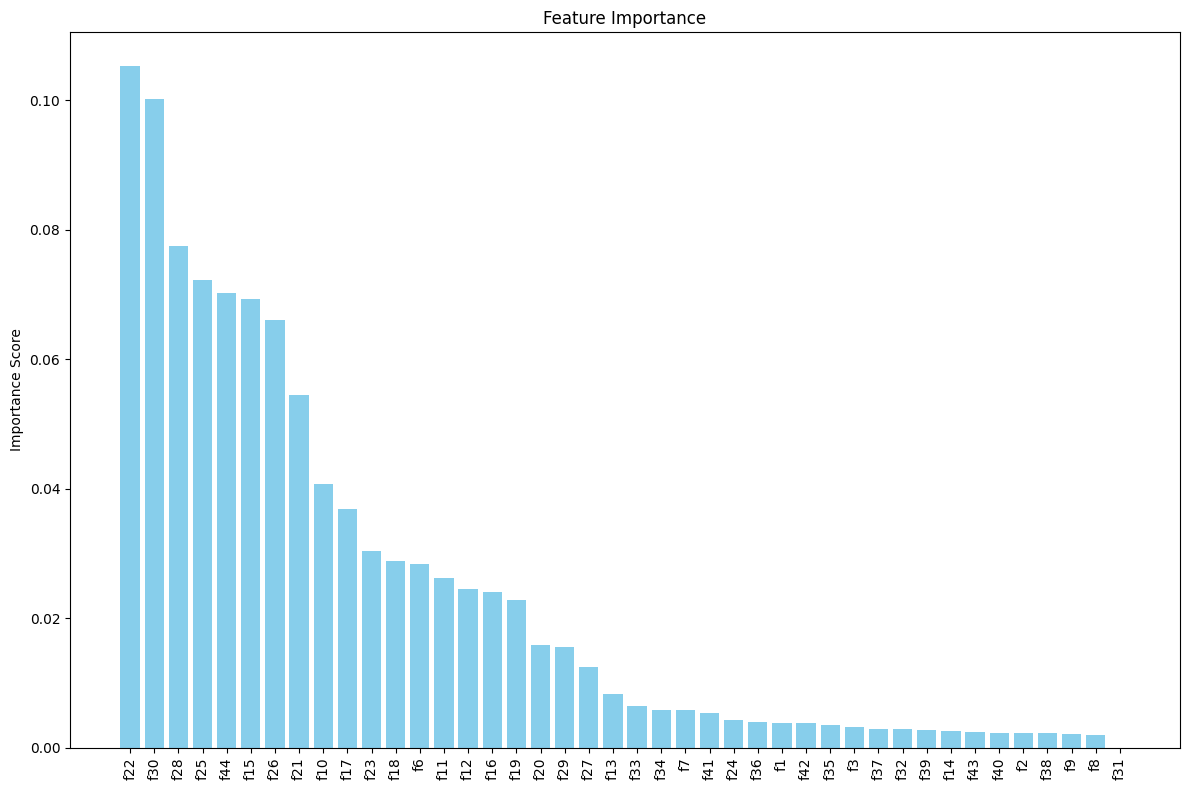

In [54]:
# b. Plot Feature Importances
model_utils.plot_feature_importance(model, title="Feature Importance")

* **How Diagnostic Rasters Work**
  "Diagnostic Rasters" are a visual representation of classification errors. The function `model_utils.save_diagnostic_rasters()` uses the production model to classify the labelled areas and compares each pixel classification to its ground truth. If a pixel is correctly classified, it has a value of zero. Otherwise, it has the classification value. The raster is used to observe where errors occur and what the errors are. The rasters are stored in `params.diagnostic_rasters_folder(is_output=True)`.

    The image below compares a diagnostic raster to its labels. Most errors occur around the borders of objects. This outcome is predictable purely because no labelling process can represent the exact border of objects.
  
<center>
  <figure>
    <img src="../images/diagnostic_raster_errors.png" alt="Diagnostic raster errors" width="40%">
    <img src="../images/diagnostic_raster_label.png" alt="Diagnostic raster labels" width="40%">
    <figcaption><i>Classification errors (left) and original labels (right)</i></figcaption>
  </figure>
</center>

  

In [61]:
# c. Save Diagnostic Data

output_folder = params.diagnostic_rasters_folder(is_output=True)

model_utils.save_diagnostic_rasters(
    model, 
    output_folder=output_folder ,
    stack_paths=fstack_numpy_files,
    meta_paths=fstack_meta_files
)

model_utils.write_metrics_report(
    metrics_dict=metrics, 
    output_path=Path(output_folder, 'metrics.txt'), 
    params_dict=model.get_params()
)

print(f"Diagnostic data saved to {output_folder}")

Diagnostic data saved to ..\data\user_data\02_model_training_and_postprocessing\diagnostic_rasters


<span style="color: red">Talk about classification experiences</span>

# 4. Model Inference
## 4.1 Increasing the "Temporal Resolution"

The GLA methodology (§2.1) incorporates imagery from multiple dates. While this decision was compulsory because the Bluesky International provider photographs London on a rolling basis, it leads to multi-seasonal imagery of vegetation. This, and the fact that Figure 1 on page 11 states that the method "uses tiles from multiple dates together" after the model has been trained, strengthens the narrative of using a higher temporal resolution during inference. Satellite imagery from multiple seasons within the same year is recommended to avoid confusing the model.  

<center>
  <figure>
    <img src="../images/hyde-park-ndvi-april-comparison.png" alt="NDVInbV values of Hyde Park in April" width="40%">
    <img src="../images/hyde-park-ndvi-November-comparison.png" alt="NDVInbV values of Hyde Park in November" width="40%">
    <figcaption><i>NDVInbV values of Hyde Park in April (left) and November (right)</i></figcaption>
  </figure>
</center>

While powerful, increasing the **temporal resolution** before inference is an entirely optional step. The function `inference.process_area_in_chunks()` in [section 4.4](#4.4-Optimised-Inference) can accommodate any temporal resolution using its dictionary input system. Therefore, the user is encouraged to experiment.

Due to LiDAR height data showing little change in the span of a single year, and that LiDAR is a harder data source to come by, the project's multi-temporal implementation is reserved for Aerial Imagery only (Blue, Green, Red, and NIR bands). The satellite data [is chosen and processed](./01_data_acquisition_and_preparation.ipynb#1.3-Satellite-data-(Aerial-Imagery)) using the same method used prior.

----
* **Multi-Temporal Data in the City of Westminster Project**

  The 30th of April 2020 Sentinel-2 image of the City of Westminster was used for training the model. Imagery from Summer (30th of July 2020) and Autumn (4th of November 2020) was incorporated into the inference process alongside the Spring imagery. The Summer and Autumn imagery will not be provided in the repository due to their large file size.

----



## 4.2 Adopting Soft Classification

Instead of the trained model performing **Hard Classification** by computing a single prediction for each pixel, **Soft Classification** may be adopted to output three probabilities, one for each class. For each pixel, the final assignment is determined by the peak probability achieved by any class over the temporal sequence. 

For example, if for a given pixel, the April probabilities were (0.33, 0.33, 0.33), the July probabilities (0.83, 0.07, 0.1), and the November probabilities (0.40, 0.55, 0.05), then the pixel is labelled as Class #1 based on the highest found probability (0.83).

This method acts as a search for the strongest evidence of a class's existence over multiple seasons. A pixel could represent Canopy, but appear as a barren patch to the model when out of season due to weak NIR signals. If that pixel had a weak probability for the Canopy class during summer and Autumn, but a high probability during spring, then that pixel is classified as Canopy.

* **Note**: If the Canopy and Green class probabilities are tied, priority is given to the Canopy class. This feature, in addition to the 4-meter binary mask appended during [feature generation](./01_data_acquisition_and_preparation.ipynb#2.2.2-Performing-Feature-Generation), increases the certainty of Canopy classification.

The function `inference.soft_classify()` is called internally within `inference.process_area_in_chunks()`.

While Soft Classification is used internally, the fact that a single label is given to each pixel by the end means that the overall process is Hard Classification. Setting the parameter `mean_prob=True` in `inference.process_area_in_chunks()` allows the output to become a Soft Classification by providing three class probabilities per pixel, each one representing the mean probability of that class over all the dates given.  

## 4.3 Optional: Enhancing Faint Vegetation Signals 

Because the original input data produces faint signals when vegetation is not dense, due to the low spatial resolution of the satellite imagery, it is unrealistic to expect the model to perform better than its input.

While faint vegetation signals may not lead to a solid classification, calling `inference.process_area_in_chunks()` using the toggle `mean_prob=True` reveals that faint vegetation probabilities are shown, even when the final output is the Neither class. 

<center>
  <figure>
    <img src="../images/top-left-chunk-soft-classification-probabilities.png" alt="Soft classification probabilities" width="40%">
    <img src="../images/top-left-chunk-soft-classification.png" alt="final classification" width="40%">
    <figcaption><i>Soft classification probabilities (left) and final classification (right). Canopy probabilities are in blue, and Green in green.</i></figcaption>
  </figure>
</center>

Using **Spatial Activation**, faint signals are boosted before final classification. It is a direct response to low-resolution data.

<center>
  <figure>
    <img src="../images/top-left-chunk-soft-classification-enhanced.png" alt="Spatially-activated classification" width="50%">
    <figcaption><i>Spatially-activated classification</i></figcaption>
  </figure>
</center>


Spatial Activation works through the following process:

1. Instead of evaluating each pixel in isolation, a Gaussian filter is used to assess a local density score for each pixel. For example, an isolated faint signal (e.g., 0.20 probability) is ignored as noise, but is validated if it forms part of a cohesive cluster, such as a tree line.
2. The pixels that belong to cohesive clusters have their probabilities passed through a **Signmoid Activation Function**.

    $$f(x) = \frac{1}{1 + e^{-k(x - x_0)}}$$

    The Threshold ($x_0$): Any vegetation with a classification probability below this threshold is not amplified. Experimentation shows that a value of 0.20 produces reasonable results.

    The Steepness ($k$): The strength of the multiplier. Set to 5.

Spatial activation may be activated by providing values to the parameter `spatial_activation` in `inference.process_area_in_chunks()`.

* **Warning**: Spatial Activation reduces the reliability of the final result. It is not a definite method of improving accuracy.

----

* **Spatial Activation in the City of Westminster Project**

  While spatial activation yielded positive results in many cases, it was ultimately decided not to be used, as the resulting classification was too exaggerated for the project.

<center>
  <figure>
    <img src="../images/top-left-corner-soft-classification.png" alt="Normal classification" width="45%">
    <img src="../images/top-left-corner-soft-classification-enhanced.png" alt="spatially activated classification" width="45%">
    <figcaption><i>Normal classification (left) and spatially activated classification (right)</i></figcaption>
  </figure>
</center>

----

## 4.4 Optimised Inference

Before performing inference, there are a couple of optimisation steps worth discussing.

### 4.4.1 Optimising Feature Engineering

The feature engineering process utilised in [2.2 Feature Generation](./01_data_acquisition_and_preparation.ipynb#2.2.2-Performing-Feature-Generation) is optimised before being called in `inference.process_area_in_chunks()`. There are a couple of key changes:

1. The features generated from the Satellite imagery (Blue, Green, Red, and NIR bands) are split from those generated by the LiDAR data (DSM and DTM). For each chunk, the LiDAR features are generated once, while the Satellite imagery features are generated for each date provided.
2. The Grey Level Co-Occurrence Matrix (GLCM) function is optimised with a stride value of 2, which performs the texture calculations every other pixel. Tweaking this parameter results in little change to the output, while reducing computation time threefold.

### 4.4.2 Inference in 'Chunks'

Unless the area to be classified is small, performing inference on the whole area at once is not feasible on consumer-grade hardware. The full area may be **split into "chunks"**, or windows, and processed separately. The `Rasterio Window` object is excellent at capturing a specific chunk of the full raster for processing. A window area can be defined, say 512x512 pixels, and the window "slides" across the full raster until it is fully captured. The parameter `chunk_size` assigns the width and height values of the square chunk.

Each chunk has the inference steps applied to it. The chunks are then stitched together before output.

* **Note on Window Overlap**:

    Unless the window's width and height are perfectly divisible by the full raster's, the window will eventually slide outside the bounds of the full raster. Therefore, the `boundless=True` parameter is set internally within `inference.process_area_in_chunks()` to mitigate this issue. 
  
* **Note on Window Buffering**:

  As discussed in [2.2 Feature Generation](./01_data_acquisition_and_preparation.ipynb#2.2.2-Performing-Feature-Generation), some engineered features require a buffer for proper computation; the maximum being 30 pixels. Each chunk is buffered internally within `inference.process_area_in_chunks()` during feature generation. The buffer is removed before output. The parameter `buffer` dictates the buffer length, in pixels.

### 4.4.3 Conducting Inference

The function `inference.process_area_in_chunks()` works by providing the core features (DSM, DTM, Blue band, Red band, Green band, NIR band). The standard parameters include the file paths to the core features, the production model path, the inference output path, the chunk size, and buffer pixels. 

In addition to the standard parameters, the optional parameters include:
* `stopping_chunk` for completing inference at the given number of chunks. It is highly recommended during testing.
*  `mean_prob` for outputting Soft Classification.
*  `spatial_activation` for applying Spatial Activation.

The features of these parameters are not activated unless a value is provided. 

* **Warning**: Inference is a time-consuming process that may take 5-10 hours depending on the classification area. 

In [8]:
# --- 1. Define the file paths ---

core_features_folder = params.full_core_features_folder()

# 1. Define the static LiDAR paths
dsm_path = Path(core_features_folder, 'fz-dsm-processed.tif')
dtm_path = Path(core_features_folder, 'dtm-processed.tif')

# 2. Define the temporal Sentinel-2 paths (one dict per date)
dates_paths = [
    {
        'blue': Path(core_features_folder, 'B02-processed.tif'),
        'green': Path(core_features_folder, 'B03-processed.tif'),
        'red': Path(core_features_folder, 'B04-processed.tif'),
        'nir': Path(core_features_folder, 'B08-processed.tif')
    },
    # Repeat the above dictionary for other dates
]

# 3. Define the 'production' model path
model_path = params.production_model_file()

# 4. Define the inference output path
inference_output = params.model_inference_file(is_output=True)

In [45]:
# --- 2. Perform the inference ---

inference.process_area_in_chunks(
    dsm_path=dsm_path, 
    dtm_path=dtm_path, 
    dates_paths=dates_paths, 
    output_path=inference_output, 
    model_path=model_path, 
    chunk_size=512, 
    buffer=30,
    # Below are the optional parameters. Uncomment as needed
    # stopping_chunk=1, 
    # mean_prob=True,   
    # spatial_activation={
    #     'Canopy': {'sigma': 1.0, 'threshold': 0.15, 'steepness': 5.0},
    #     'Green': {'sigma': 1.0, 'threshold': 0.25, 'steepness': 5.0}
    # }
)

[2026-04-04 21:07:55.036410] Starting Westminster Pipeline...
Loading Random Forest model into memory...
Mode: Hard Classification
Creating output raster at ..\data\user_data\02_model_training_and_postprocessing\green_cover_map\model_inferencen_estimators86njobs.tif...
Processing Chunk 1 | Window at X:0, Y:0
[2026-04-04 21:11:35.219647] Stopping chunk limit (1) reached. Terminating early.


In [10]:
print(f"The unprocessed inference is stored at: {params.model_inference_file()}")

The unprocessed inference is stored at: ..\data\westminster_data\02_model_training_and_postprocessing\green_cover_map\1_model_inference.tif


# 5. Postprocessing

The input required for this section is the inference raster stored at `params.model_inference_file()`.

The final goal for this section is to have a vector cover for both the Canopy and Green classes. The GLA's cover can be found at https://apps.london.gov.uk/green-cover.

## 5.1 Morphological Smoothing

The GLA methodology (§2.4.1) details the application of **morphological image processing** using OpenCV. The purpose is to remove noise and smooth the classification by successively shrinking and expanding pixels. The function `postprocessing.apply_morphological_smoothing()` separates the inference raster into Canopy and Green covers, before applying smoothing to each. 

The parameter `kernel_size` dictates the size of the smoothing kernel (e.g., a 3x3 kernel). A value of 3 is recommended. Only odd values may be used for the kernel, as even values shift the image.

In [16]:
print(f"The smoothed cover is stored at: {params.smoothed_cover_file()}")

The smoothed cover is stored at: ..\data\westminster_data\02_model_training_and_postprocessing\green_cover_map\2_smoothed_cover.tif


In [22]:
inference_raster = params.model_inference_file()
smoothed_cover = params.smoothed_cover_file(is_output=True)

postprocessing.apply_morphological_smoothing(
    input_path=inference_raster, 
    output_path=smoothed_cover, 
    kernel_size=3
)

Smooth raster saved to: ..\data\user_data\02_model_training_and_postprocessing\green_cover_map\2_smoothed_cover.tif


## 5.2 Cover Vectorisation

The next step is to convert the smoothed raster to a **shapefile (.shp)** for viewing and analysis. The function `inference.vectorise_raster()` converts the Green and Canopy classes into separate vector files.


In [15]:
print(f"The vectorised Canopy cover is stored at: {params.vectorised_canopy_cover_file()}")
print(f"The vectorised Green cover is stored at: {params.vectorised_green_cover_file()}")

The vectorised Canopy cover is stored at: ..\data\westminster_data\02_model_training_and_postprocessing\green_cover_map\3_vectorised_canopy_cover.tif
The vectorised Green cover is stored at: ..\data\westminster_data\02_model_training_and_postprocessing\green_cover_map\3_vectorised_green_cover.tif


In [ ]:
smoothed_cover = params.smoothed_cover_file()
vectorised_canopy_cover = params.vectorised_canopy_cover_file(is_output=True)
vectorised_green_cover = params.vectorised_green_cover_file(is_output=True)

postprocessing.vectorise_raster(
    input_path=smoothed_cover, 
    output_canopy=vectorised_canopy_cover, 
    output_green=vectorised_green_cover
)

## 5.3 Improving Cover with Vector Data

The GLA methodology (§2.4.3) details the use of **the Ordnance Survey MasterMap (OSMM)** to address certain blind spots in the vectorised classification. According to the report, the classification "does not do well at categorising areas of dry grass, or bare field, as vegetation" and that certain land "should be counted as green cover but are not always ‘green’ due to the cycle of planting and harvest". Appendix 4 lists the categories that were extracted from the OSMM and appended to the green classification. The canopy classification is untouched.

OSMM is not freely available for independent users. Therefore, similar vector datasets must be found for the classification area. The process for finding and applying such vector data differs heavily, depending on where the classification is made. Below is the process that may be applied anywhere within Greater London.

----
**Improving the City of Westminster Cover**

Three sources were found that could offer comparable categories to those listed in Appendix 4:

1. Ordnance Survey OpenMap Local

   Layers used: TQ_Woodland.shp, TQ_SurfaceWater_Area.shp
   
   Find at: https://www.ordnancesurvey.co.uk/products/os-open-map-local

   
   
2. Ordnance Survey Open Greenspace

   Layers used: TG_GreenspaceSite.shp

   Find at: https://www.ordnancesurvey.co.uk/products/os-open-greenspace

   

3. Geofabrik OpenStreetMap

   Layers used: gis_osm_landuse_a_free_1.shp, gis_osm_pois_a_free_1

   Find at: https://download.geofabrik.de/europe/united-kingdom/england/greater-london.html

* Note: the TQ_SurfaceWater_Area layer was used to add water to the final cover. 

Using QGIS, the layers mentioned above were clipped to the City of Westminster's Minimum Bounding Box. The layers were filtered to contain features similar to those listed in Appendix 4. The following table lists the chosen features:

| Layer Name | Feature |
| :--- | :--- |
| **TG_GreenspaceSite** | Allotments Or Community Growing Spaces |
| **TG_GreenspaceSite** | Public Park Or Garden |
| **TG_GreenspaceSite** | Playing Field |
| **TG_GreenspaceSite** | Bowling Green |
| **TG_GreenspaceSite** | Cemetery |
| **TG_GreenspaceSite** | Religious Grounds |
| **TG_GreenspaceSite** | Other Sports Facility |
| **TQ_Woodland** | Feature 15999 |
| **gis_osm_pois_a_free_1** | park |
| **gis_osm_pois_a_free_1** | dog_park |
| **gis_osm_pois_a_free_1** | golf_course |
| **gis_osm_pois_a_free_1** | pitch |
| **gis_osm_pois_a_free_1** | graveyard |
| **gis_osm_pois_a_free_1** | garden_centre |
| **gis_osm_landuse_a_free_1** | scrub |
| **gis_osm_landuse_a_free_1** | heath |
| **gis_osm_landuse_a_free_1** | forest |
| **gis_osm_landuse_a_free_1** | orchard |
| **gis_osm_landuse_a_free_1** | grass |
| **gis_osm_landuse_a_free_1** | meadow |
| **gis_osm_landuse_a_free_1** | allotments |
| **gis_osm_landuse_a_free_1** | park |
| **gis_osm_landuse_a_free_1** | recreation_ground |
| **gis_osm_landuse_a_free_1** | nature_reserve |
| **gis_osm_landuse_a_free_1** | cemetery |

Once filtered, the features of all layers were merged using the `Merge vector layers` and `Dissolve` tools in QGIS. Using the Google Satellite layer, all features within the merged vector were manually inspected for quality control.

The City of Westminster cover files can be found at: data\westminster_data\02_model_training_and_postprocessing\green_cover_map.

----


In [17]:
print(f"The imporved green cover is stored at: {params.improved_green_cover_file()}")

The imporved green cover is stored at: ..\data\westminster_data\02_model_training_and_postprocessing\green_cover_map\4_enhanced_green_cover.tif


Credits:

* **Ordnance Survey Data**:

  
    Contains OS data © Crown copyright and database right 2026. Licensed under the Open Government Licence v3.0.

* **OpenStreetMap Data**:

    Map data © OpenStreetMap contributors, available under the Open Database License. Data retrieved via Geofabrik.